In [1]:
# importing my libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
from cleaning_utilitis import (handle_missing, fix_dtypes, remove_outliers, remove_duplicates, clean_strings)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [3]:
# pushing to sqlite database inorder to query the data

conn = sqlite3.connect('stroke_data.db')
df.to_sql('stroke', conn, if_exists='replace', index=False)
print("DataFrame has been pushed to SQLite database successfully.")

DataFrame has been pushed to SQLite database successfully.


In [4]:
# saving a raw copy of the data for later use
df_raw = df.copy()

In [5]:
pd.read_sql_query("""
    SELECT *
    FROM stroke;
    """, conn)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [6]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_records, 
       SUM(CASE WHEN stroke = 1 THEN 1 ELSE 0 END) AS stroke_cases, 
       SUM(CASE WHEN stroke = 0 THEN 1 ELSE 0 END) AS non_stroke_cases
FROM stroke;
""", conn
)

,total_records,stroke_cases,non_stroke_cases
0,5110,249,4861


In [7]:
pd.read_sql_query("""
        SELECT COUNT(*) AS total_records, gender, 
                  SUM(CASE WHEN stroke = 1 THEN 1 ELSE 0 END) AS stroke_cases,
                  ROUND(100.0 * SUM(CASE WHEN stroke = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS stroke_percentage
        FROM stroke
        GROUP BY gender;          

""", conn)

,total_records,gender,stroke_cases,stroke_percentage
0,2994,Female,141,4.71
1,2115,Male,108,5.11
2,1,Other,0,0.00


In [8]:
pd.read_sql_query("""
SELECT work_type, COUNT(*) AS count, SUM(CASE WHEN stroke = 1 THEN 1 ELSE 0 END) AS stroke_cases, ROUND(100.0 * SUM(CASE WHEN stroke = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS stroke_percentage
FROM stroke
GROUP BY work_type;
""", conn)

,work_type,count,stroke_cases,stroke_percentage
0,Govt_job,657,33,5.02
1,Never_worked,22,0,0.00
2,Private,2925,149,5.09
3,Self-employed,819,65,7.94
4,children,687,2,0.29


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


There are missing values in bmi, we would explore the data inorder to know how to fix that.

In [10]:
df.describe(include="all")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [11]:
missing = df.isnull().sum()
print(missing[missing > 0])

bmi    201
dtype: int64


In [12]:
# filling missing values on bmi with the median value
instructions = {
    'bmi': 'median'
}

df = handle_missing(df, instructions, fill_value=None)

In [13]:
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])
print("There are no more missing values!")

Series([], dtype: int64)
There are no more missing values!


In [14]:
# removing duplicates
df = remove_duplicates(df)

Removed 0 duplicate rows — 5110 rows remaining


In [15]:
# clean strings
df = clean_strings(df)

Cleaned 5 string column(s)


In [16]:
# remove outliers
df = remove_outliers(df, column_name='bmi', method='IQR', action='remove')

Removed 126 outlier rows -- 4984 rows remaining


Outliers were removed on bmi column.

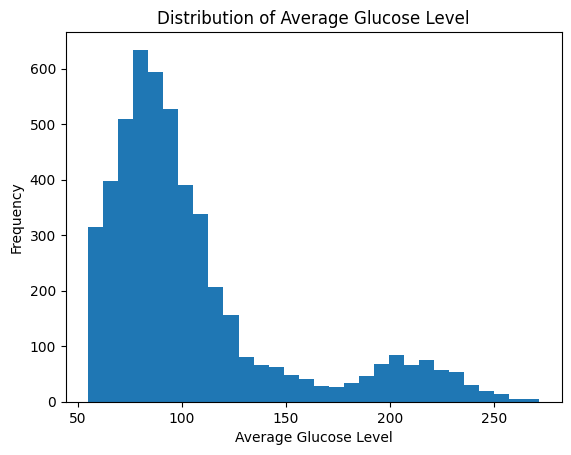

In [17]:
plt.hist(df['avg_glucose_level'], bins=30)
plt.title('Distribution of Average Glucose Level')
plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.show()

High glucose values (200+) were retained. Research indicates individuals 
with diabetes or hyperglycemia can have glucose levels above 250mg/dL. 
Removing these would bias the model against high-risk patients.

## FEATURE ENGINEERING

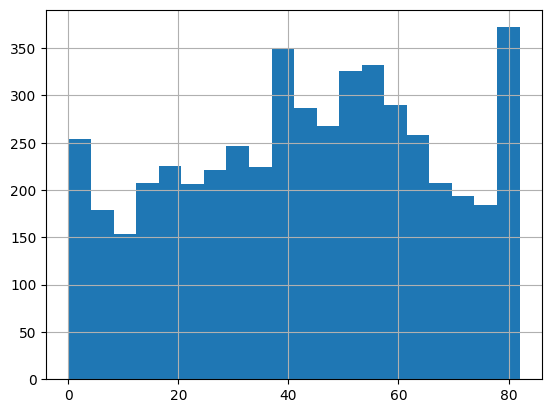

In [18]:
df['age'].hist(bins=20)
plt.show()

In [19]:
df.groupby(pd.cut(df['age'], bins=10))['stroke'].mean()

age
(-0.00192, 8.272]    0.002309
(8.272, 16.464]      0.002770
(16.464, 24.656]     0.000000
(24.656, 32.848]     0.002137
(32.848, 41.04]      0.008726
(41.04, 49.232]      0.019820
(49.232, 57.424]     0.048632
(57.424, 65.616]     0.072993
(65.616, 73.808]     0.109726
(73.808, 82.0]       0.199640
Name: stroke, dtype: float64

In [20]:
df.groupby(pd.cut(df['avg_glucose_level'], bins=10))['stroke'].mean()

avg_glucose_level
(54.903, 76.782]      0.045008
(76.782, 98.444]      0.031357
(98.444, 120.106]     0.039530
(120.106, 141.768]    0.032895
(141.768, 163.43]     0.032680
(163.43, 185.092]     0.125000
(185.092, 206.754]    0.140704
(206.754, 228.416]    0.125000
(228.416, 250.078]    0.144231
(250.078, 271.74]     0.208333
Name: stroke, dtype: float64

In [21]:
# Binning continnous categories like age, bmi and avg_glucose_level
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 41, 65, np.inf], labels=['child', 'young_adult', 'adult', 'elderly'])
df['bmi_group'] = pd.cut(df['bmi'], labels=['underweight', 'normal', 'overweight', 'obese'], bins=[0, 18.5, 25, 30, np.inf])
df['glucose_group'] = pd.cut(df['avg_glucose_level'], bins=[0, 70, 100, 126, np.inf], labels=['Low', 'Normal', 'Prediabetic', 'Diabetic'])

In [22]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_group,glucose_group
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly smoked,1,elderly,obese,Diabetic
1,51676,female,61.0,0,0,yes,self-employed,rural,202.21,28.1,never smoked,1,adult,overweight,Diabetic
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never smoked,1,elderly,obese,Prediabetic
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1,adult,obese,Diabetic
4,1665,female,79.0,1,0,yes,self-employed,rural,174.12,24.0,never smoked,1,elderly,normal,Diabetic


In [23]:
df['cardiovascular_risk'] = df['hypertension'] + df['heart_disease']

In [24]:
df['cardiovascular_risk'].value_counts()

cardiovascular_risk
0    4296
1     624
2      64
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 4984 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   4984 non-null   int64   
 1   gender               4984 non-null   str     
 2   age                  4984 non-null   float64 
 3   hypertension         4984 non-null   int64   
 4   heart_disease        4984 non-null   int64   
 5   ever_married         4984 non-null   str     
 6   work_type            4984 non-null   str     
 7   Residence_type       4984 non-null   str     
 8   avg_glucose_level    4984 non-null   float64 
 9   bmi                  4984 non-null   float64 
 10  smoking_status       4984 non-null   str     
 11  stroke               4984 non-null   int64   
 12  age_group            4984 non-null   category
 13  bmi_group            4984 non-null   category
 14  glucose_group        4984 non-null   category
 15  cardiovascular_risk  4984 non-null   

In [26]:
# dropping id from the dataset as it is not useful for modeling

df = df.drop(columns=['id'])

In [27]:
ohe_cols = ['gender', 'ever_married', 'work_type', 'Residence_type','smoking_status']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

In [28]:
mapping = {
    'age_group': {'child': 0, 'young_adult': 1, 'adult': 2, 'elderly': 3},
    'bmi_group': {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3},
    'glucose_group': {'Low': 0, 'Normal': 1, 'Prediabetic': 2, 'Diabetic': 3}
}

for col, mapping in mapping.items():
    df[col] = df[col].map(mapping)


In [29]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,age_group,bmi_group,glucose_group,cardiovascular_risk,...,gender_other,ever_married_yes,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self-employed,Residence_type_urban,smoking_status_never smoked,smoking_status_smokes,smoking_status_unknown
0,67.0,0,1,228.69,36.6,1,3,3,3,1,...,0,1,0,0,1,0,1,0,0,0
1,61.0,0,0,202.21,28.1,1,2,2,3,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,3,3,2,1,...,0,1,0,0,1,0,0,1,0,0
3,49.0,0,0,171.23,34.4,1,2,3,3,0,...,0,1,0,0,1,0,1,0,1,0
4,79.0,1,0,174.12,24.0,1,3,1,3,1,...,0,1,0,0,0,1,0,1,0,0


In [30]:
df['stroke'].value_counts()

stroke
0    4738
1     246
Name: count, dtype: int64

In [31]:
# defining my features and target variable
X = df.drop(columns=['stroke'])
y = df['stroke']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [33]:
# scaling features
scaler = StandardScaler()
X_train[['age', 'bmi', 'avg_glucose_level']] = scaler.fit_transform(X_train[['age', 'bmi', 'avg_glucose_level']])
X_test[['age', 'bmi', 'avg_glucose_level']] = scaler.transform(X_test[['age', 'bmi', 'avg_glucose_level']])


In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [35]:

print(classification_report(y_test, lr_pred))
print(roc_auc_score(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       948
           1       0.15      0.88      0.26        49

    accuracy                           0.75       997
   macro avg       0.57      0.81      0.55       997
weighted avg       0.95      0.75      0.82       997

0.8111383794023939


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample',
    n_estimators=200,
    min_samples_leaf=5
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [37]:
print(classification_report(y_test, rf_pred))
print(roc_auc_score(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       948
           1       0.25      0.33      0.28        49

    accuracy                           0.92       997
   macro avg       0.61      0.64      0.62       997
weighted avg       0.93      0.92      0.92       997

0.6379488504262464


In [44]:
cat_cols = ['age_group', 'bmi_group', 'glucose_group']
X_train[cat_cols] = X_train[cat_cols].astype(int)
X_test[cat_cols] = X_test[cat_cols].astype(int)

In [45]:
from xgboost import XGBClassifier

scale_pos_weight = 4738 / 246

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print(classification_report(y_test, xgb_pred))
print(roc_auc_score(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       948
           1       0.22      0.24      0.23        49

    accuracy                           0.92       997
   macro avg       0.59      0.60      0.60       997
weighted avg       0.92      0.92      0.92       997

0.6002970808576595
